# Explore CALCE Dataset

This notebook loads and inspects the CALCE.npy dataset, exploring its battery-level contents and summarizing available features.

In [1]:
# Section 1: Import Libraries and Configure Paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# Define paths
calce_path = 'datasets/CALCE/CALCE.npy'

# Check if file exists
if os.path.exists(calce_path):
    print(f"✓ File found: {calce_path}")
else:
    print(f"✗ File NOT found: {calce_path}")

✓ File found: datasets/CALCE/CALCE.npy


In [2]:
# Section 2: Load CALCE.npy Safely
print("Loading CALCE.npy...")
try:
    Battery = np.load(calce_path, allow_pickle=True)
    print(f"Raw loaded object type: {type(Battery)}")
    
    # Convert if needed
    Battery = Battery.item()
    print(f"After .item() conversion type: {type(Battery)}")
    print(f"✓ Dataset loaded successfully!")
except Exception as e:
    print(f"✗ Error loading dataset: {e}")

Loading CALCE.npy...
Raw loaded object type: <class 'numpy.ndarray'>
After .item() conversion type: <class 'dict'>
✓ Dataset loaded successfully!


In [3]:
# Section 3: Inspect Top-Level Object Structure
print("="*70)
print("TOP-LEVEL STRUCTURE")
print("="*70)
print(f"Object type: {type(Battery)}")
print(f"Total entries: {len(Battery)}")
print(f"Keys/Batteries: {list(Battery.keys())}")
print(f"\nFirst entry type: {type(list(Battery.values())[0])}")

TOP-LEVEL STRUCTURE
Object type: <class 'dict'>
Total entries: 4
Keys/Batteries: ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']

First entry type: <class 'pandas.DataFrame'>


In [4]:
# Section 4: List Available Battery Keys
print("="*70)
print("AVAILABLE BATTERIES")
print("="*70)
for i, (battery_id, data) in enumerate(Battery.items(), 1):
    print(f"{i}. {battery_id}")
    print(f"   Type: {type(data)}")
    if hasattr(data, 'shape'):
        print(f"   Shape: {data.shape}")
    if hasattr(data, 'columns'):
        print(f"   Columns: {len(data.columns)}")
    print()

AVAILABLE BATTERIES
1. CS2_35
   Type: <class 'pandas.DataFrame'>
   Shape: (882, 6)
   Columns: 6

2. CS2_36
   Type: <class 'pandas.DataFrame'>
   Shape: (936, 6)
   Columns: 6

3. CS2_37
   Type: <class 'pandas.DataFrame'>
   Shape: (972, 6)
   Columns: 6

4. CS2_38
   Type: <class 'pandas.DataFrame'>
   Shape: (996, 6)
   Columns: 6



In [5]:
# Section 5: Preview One Battery DataFrame
print("="*70)
print("SAMPLE BATTERY: First Battery")
print("="*70)
battery_list = list(Battery.keys())
first_battery = battery_list[0]
df_first = Battery[first_battery]

print(f"Battery ID: {first_battery}")
print(f"Shape: {df_first.shape}")
print(f"Columns: {df_first.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_first.head())
print(f"\nData types:")
print(df_first.dtypes)

SAMPLE BATTERY: First Battery
Battery ID: CS2_35
Shape: (882, 6)
Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']

First 5 rows:
   cycle  capacity       SoH  resistance         CCCT         CVCT
0    1.0  1.126385  0.825175    0.094009  6613.059052  2251.498033
1    2.0  1.126160  0.815965    0.091661  6612.402800  2231.967052
2    3.0  1.125966  0.815977    0.094649  6608.560673  2228.216959
3    4.0  1.118508  0.825194    0.091413  6604.732222  2247.561061
4    5.0  1.117210  0.806900    0.091413  6629.211049  2077.692393

Data types:
cycle         float64
capacity      float64
SoH           float64
resistance    float64
CCCT          float64
CVCT          float64
dtype: object


In [6]:
# Section 6: Check Columns and Data Types Across Batteries
print("="*70)
print("COLUMNS AND DATA TYPES - ALL BATTERIES")
print("="*70)
for battery_name in battery_list:
    df = Battery[battery_name]
    print(f"\n{battery_name}:")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Data types: {df.dtypes.tolist()}")
    
    # Check for expected columns
    expected = ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
    found = [col for col in expected if col in df.columns]
    missing = [col for col in expected if col not in df.columns]
    print(f"  Expected columns found: {found}")
    if missing:
        print(f"  Missing: {missing}")

COLUMNS AND DATA TYPES - ALL BATTERIES

CS2_35:
  Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
  Data types: [dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]
  Expected columns found: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']

CS2_36:
  Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
  Data types: [dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]
  Expected columns found: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']

CS2_37:
  Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
  Data types: [dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]
  Expected columns found: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']

CS2_38:
  Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
  Data types: [dtype(

In [7]:
# Section 7: Measure Shapes, Missing Values, and Basic Statistics
print("="*70)
print("DATA QUALITY - SHAPES, MISSING VALUES, STATISTICS")
print("="*70)
for battery_name in battery_list:
    df = Battery[battery_name]
    print(f"\n{battery_name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Total missing values: {df.isnull().sum().sum()}")
    print(f"  Valid rows: {len(df) - df.isnull().any(axis=1).sum()}")
    print(f"\n  Summary statistics:")
    print(df.describe().round(4))

DATA QUALITY - SHAPES, MISSING VALUES, STATISTICS

CS2_35:
  Shape: (882, 6)
  Total missing values: 18
  Valid rows: 864

  Summary statistics:
          cycle  capacity       SoH  resistance       CCCT       CVCT
count  882.0000  882.0000  882.0000    882.0000   882.0000   864.0000
mean   441.5000    0.8551    0.6169      0.0994  4717.1362  2541.8758
std    254.7558    0.2082    0.1859      0.0097  1482.2857   506.6119
min      1.0000    0.2567    0.1008      0.0850     0.0000     0.0000
25%    221.2500    0.7426    0.5501      0.0930  3874.2829  2224.3025
50%    441.5000    0.9519    0.7060      0.0964  5326.3016  2514.5720
75%    661.7500    0.9960    0.7334      0.1037  5750.6593  2907.1846
max    882.0000    1.1264    0.8252      0.1232  6629.2110  3659.1247

CS2_36:
  Shape: (936, 6)
  Total missing values: 13
  Valid rows: 923

  Summary statistics:
          cycle  capacity       SoH  resistance       CCCT       CVCT
count  936.0000  936.0000  936.0000    936.0000   936.0000  

In [8]:
# Section 8: Compare Common Numeric Features
print("="*70)
print("COMMON NUMERIC FEATURES - CROSS-BATTERY COMPARISON")
print("="*70)
# Find common numeric columns
common_cols = set(Battery[battery_list[0]].select_dtypes(include=[np.number]).columns)
for battery_name in battery_list[1:]:
    cols_set = set(Battery[battery_name].select_dtypes(include=[np.number]).columns)
    common_cols = common_cols.intersection(cols_set)

common_cols = sorted(list(common_cols))
print(f"\nCommon numeric columns: {common_cols}")

# Build comparison table
comparison_data = []
for battery_name in battery_list:
    df = Battery[battery_name]
    for col in common_cols:
        comparison_data.append({
            'Battery': battery_name,
            'Feature': col,
            'Mean': df[col].mean(),
            'Std': df[col].std(),
            'Min': df[col].min(),
            'Max': df[col].max()
        })

comparison_df = pd.DataFrame(comparison_data)
print(f"\nFeature Comparison Table:")
print(comparison_df.to_string(index=False))

COMMON NUMERIC FEATURES - CROSS-BATTERY COMPARISON

Common numeric columns: ['CCCT', 'CVCT', 'SoH', 'capacity', 'cycle', 'resistance']

Feature Comparison Table:
Battery    Feature        Mean         Std        Min         Max
 CS2_35       CCCT 4717.136205 1482.285660   0.000000 6629.211049
 CS2_35       CVCT 2541.875751  506.611904   0.000000 3659.124675
 CS2_35        SoH    0.616943    0.185902   0.100836    0.825194
 CS2_35   capacity    0.855104    0.208222   0.256677    1.126385
 CS2_35      cycle  441.500000  254.755765   1.000000  882.000000
 CS2_35 resistance    0.099438    0.009659   0.085018    0.123185
 CS2_36       CCCT 4539.825729 1780.849907 119.560680 6693.788570
 CS2_36       CVCT 2499.195839  476.772621   0.000000 3656.704530
 CS2_36        SoH    0.585501    0.219250   0.045847    0.825405
 CS2_36   capacity    0.822947    0.259221   0.137548    1.133807
 CS2_36      cycle  468.500000  270.344225   1.000000  936.000000
 CS2_36 resistance    0.096466    0.011233   0


Generating degradation plots...


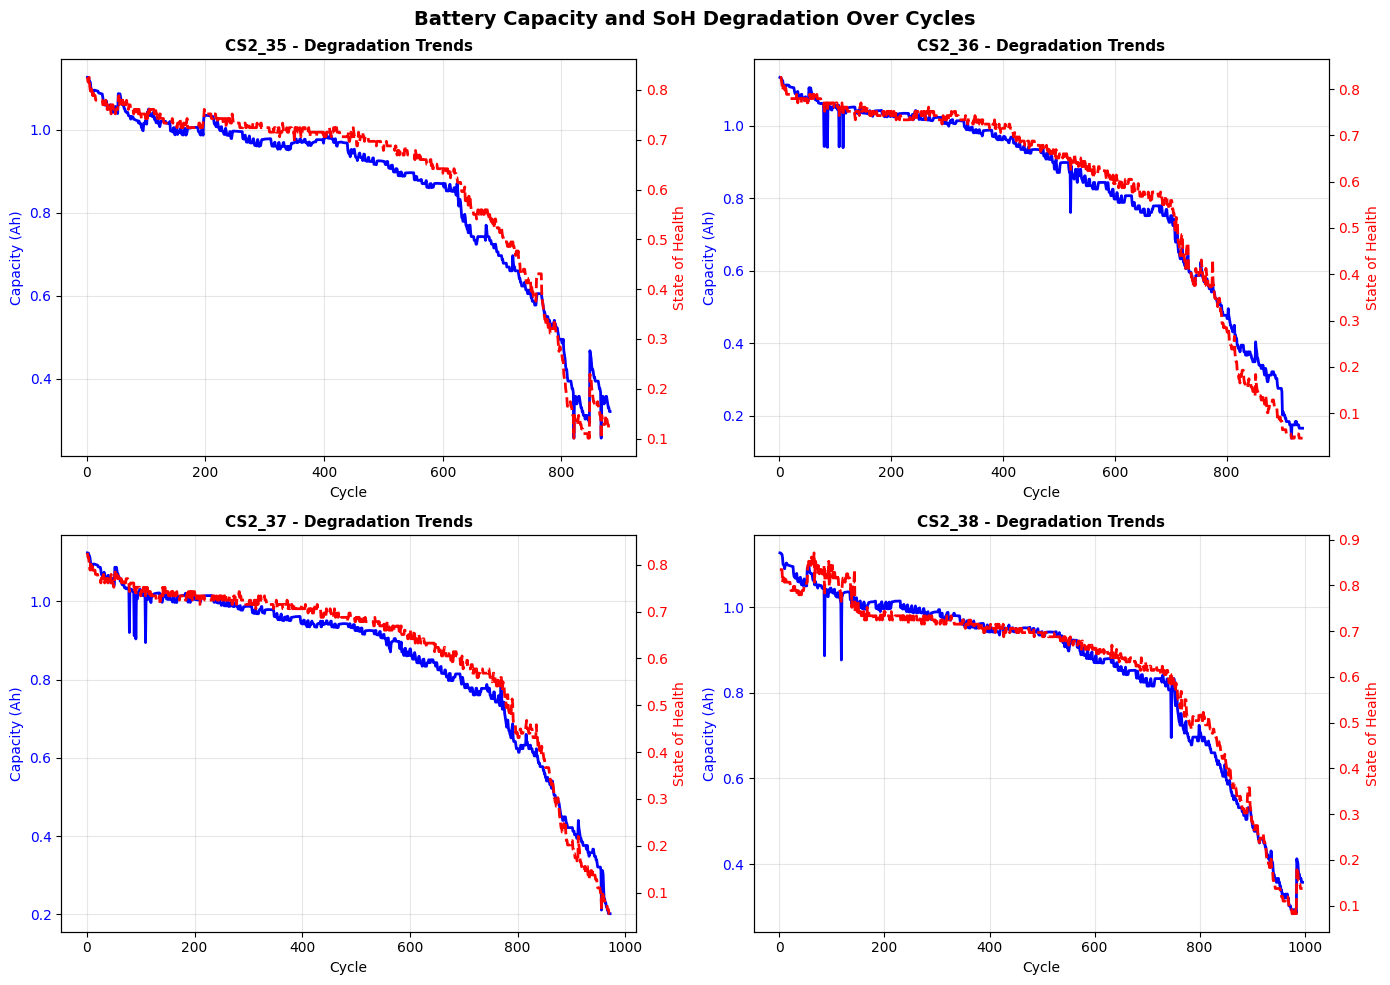

In [9]:
# Section 9: Plot Capacity and SoH Trends
print("\nGenerating degradation plots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, battery_name in enumerate(battery_list):
    df = Battery[battery_name]
    ax = axes[idx]
    
    # Plot capacity vs cycle
    ax.plot(df['cycle'], df['capacity'], 'b-', linewidth=2, label='Capacity')
    ax_twin = ax.twinx()
    ax_twin.plot(df['cycle'], df['SoH'], 'r--', linewidth=2, label='SoH')
    
    ax.set_xlabel('Cycle', fontsize=10)
    ax.set_ylabel('Capacity (Ah)', color='b', fontsize=10)
    ax_twin.set_ylabel('State of Health', color='r', fontsize=10)
    ax.set_title(f'{battery_name} - Degradation Trends', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='y', labelcolor='b')
    ax_twin.tick_params(axis='y', labelcolor='r')

plt.suptitle('Battery Capacity and SoH Degradation Over Cycles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Section 10: Export Inspection Summaries
print("="*70)
print("EXPORTING SUMMARIES TO CSV")
print("="*70)

# Save comparison table
comparison_df.to_csv('calce_feature_comparison.csv', index=False)
print(f"✓ Saved: calce_feature_comparison.csv")

# Save battery-level summary
battery_summary = []
for battery_name in battery_list:
    df = Battery[battery_name]
    battery_summary.append({
        'Battery_ID': battery_name,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Missing_Values': df.isnull().sum().sum(),
        'Avg_Capacity': df['capacity'].mean(),
        'Final_SoH': df['SoH'].iloc[-1],
        'Capacity_Degradation': df['capacity'].iloc[0] - df['capacity'].iloc[-1]
    })

battery_summary_df = pd.DataFrame(battery_summary)
battery_summary_df.to_csv('calce_battery_summary.csv', index=False)
print(f"✓ Saved: calce_battery_summary.csv")

# Display summary
print(f"\nBattery Summary:")
print(battery_summary_df.to_string(index=False))

EXPORTING SUMMARIES TO CSV
✓ Saved: calce_feature_comparison.csv
✓ Saved: calce_battery_summary.csv

Battery Summary:
Battery_ID  Rows  Columns  Missing_Values  Avg_Capacity  Final_SoH  Capacity_Degradation
    CS2_35   882        6              18      0.855104   0.119174              0.805521
    CS2_36   936        6              13      0.822947   0.045847              0.968747
    CS2_37   972        6              14      0.847870   0.055010              0.922543
    CS2_38   996        6              10      0.853773   0.137498              0.769463
